# Netflix Content Analysis

This project analyzes Netflix’s content catalog to uncover trends in:

- Content growth over time  
- Differences between movies and TV shows  
- Content quality (IMDb ratings)  
- Duration patterns  
- Global production distribution  
- Genre dominance  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Dataset Overview & Cleaning

**Goal:** Load and prepare the dataset for analysis.

In [2]:
df = pd.read_csv("titles.csv")

df = df.drop(columns=["age_certification"])
df["seasons"] = df["seasons"].fillna(0)

df.head()

,id,title,type,description,release_year,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,114,"['drama', 'crime']",['US'],0.0,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,109,"['drama', 'action', 'thriller', 'european']",['US'],0.0,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,91,"['fantasy', 'action', 'comedy']",['GB'],0.0,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,150,"['war', 'action']","['GB', 'US']",0.0,tt0061578,7.7,72662.0,20.398,7.600


## 2. Content Growth Over Time

**Goal:** Analyze how Netflix’s content library has expanded over time.

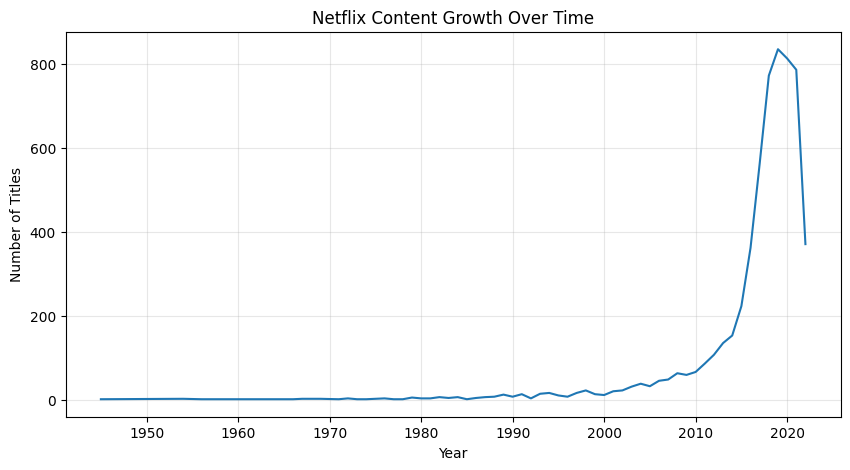

In [3]:
years_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
years_counts.plot()

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)

plt.show()

**Key Insight:**  
Content production increases significantly after 2010, peaking around 2019.

**Interpretation:**  
This reflects Netflix’s rapid expansion as it transitioned into a major content producer.

## 3. Movies vs TV Shows

**Goal:** Compare how movies and TV shows contributed to Netflix’s growth.

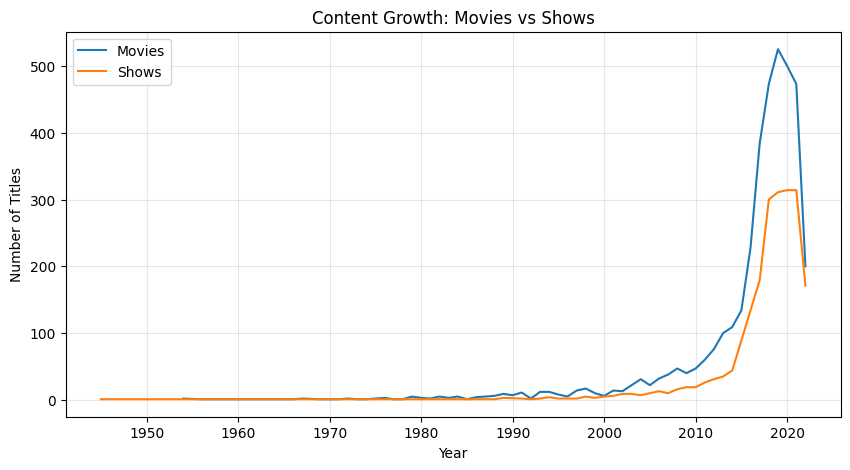

In [4]:
movies = df[df["type"] == "MOVIE"]
shows = df[df["type"] == "SHOW"]

movie_counts = movies["release_year"].value_counts().sort_index()
show_counts = shows["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
movie_counts.plot(label="Movies")
show_counts.plot(label="Shows")

plt.legend()
plt.title("Content Growth: Movies vs Shows")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)

plt.show()

**Key Insight:**  
Movies dominate early growth, while TV shows accelerate after 2015.

**Interpretation:**  
Netflix increasingly invests in serialized content to drive engagement.

## 4. Quality Comparison (IMDb Ratings)

**Goal:** Compare content quality between movies and TV shows.

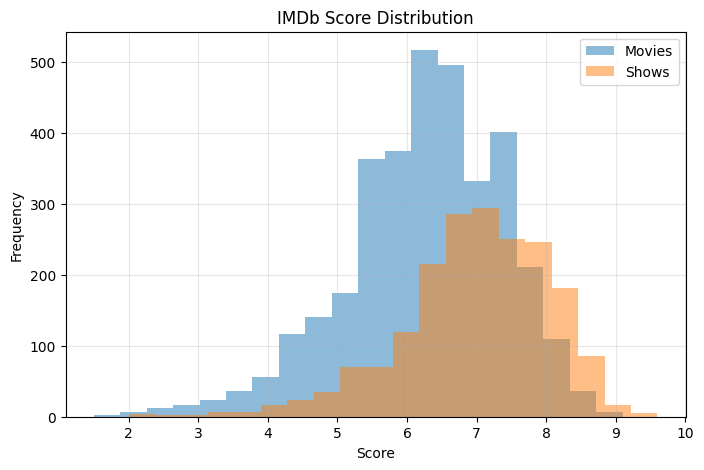

In [5]:
movies_scores = movies["imdb_score"].dropna()
shows_scores = shows["imdb_score"].dropna()

plt.figure(figsize=(8,5))
movies_scores.hist(bins=20, alpha=0.5, label="Movies")
shows_scores.hist(bins=20, alpha=0.5, label="Shows")

plt.legend()
plt.title("IMDb Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

**Key Insight:**  
TV shows tend to have higher and more consistent ratings than movies.

**Interpretation:**  
Serialized storytelling allows for deeper audience engagement and stronger reception.

## 5. Content Characteristics

**Goal:** Analyze how content length has evolved over time.

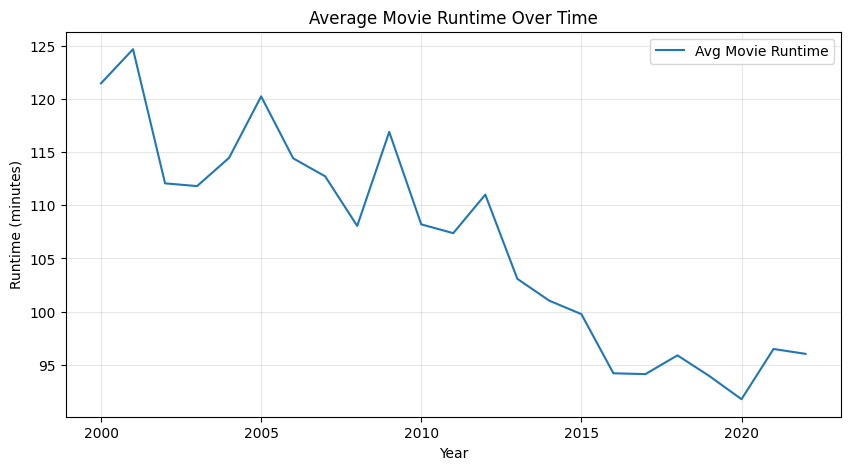

In [6]:
movie_runtime_trend = movies.groupby("release_year")["runtime"].mean()
movie_runtime_trend = movie_runtime_trend[movie_runtime_trend.index >= 2000]

plt.figure(figsize=(10,5))
movie_runtime_trend.plot(label="Avg Movie Runtime")

plt.title("Average Movie Runtime Over Time")
plt.xlabel("Year")
plt.ylabel("Runtime (minutes)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

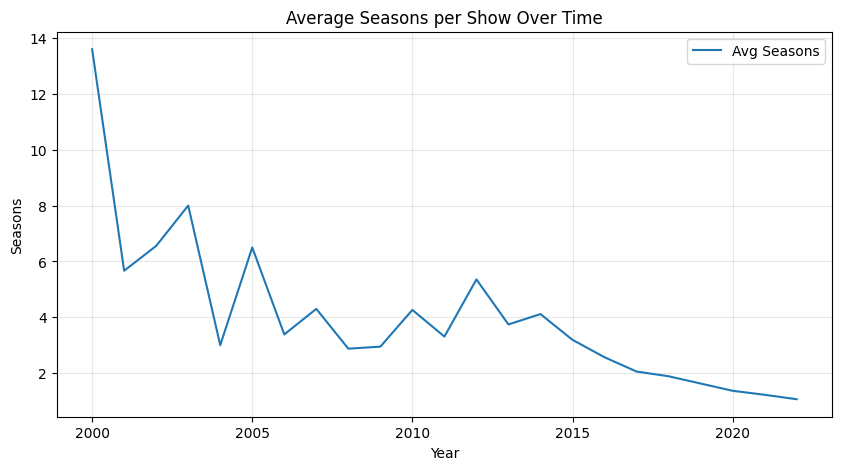

In [7]:
show_seasons_trend = shows.groupby("release_year")["seasons"].mean()
show_seasons_trend = show_seasons_trend[show_seasons_trend.index >= 2000]

plt.figure(figsize=(10,5))
show_seasons_trend.plot(label="Avg Seasons")

plt.title("Average Seasons per Show Over Time")
plt.xlabel("Year")
plt.ylabel("Seasons")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Key Insight:**  
Movie runtimes are decreasing, while TV show length remains relatively stable.

**Interpretation:**  
Netflix favors shorter movies and limited-series formats to match viewer behavior.

## 6. Global Production Landscape

**Goal:** Identify the main countries producing Netflix content.

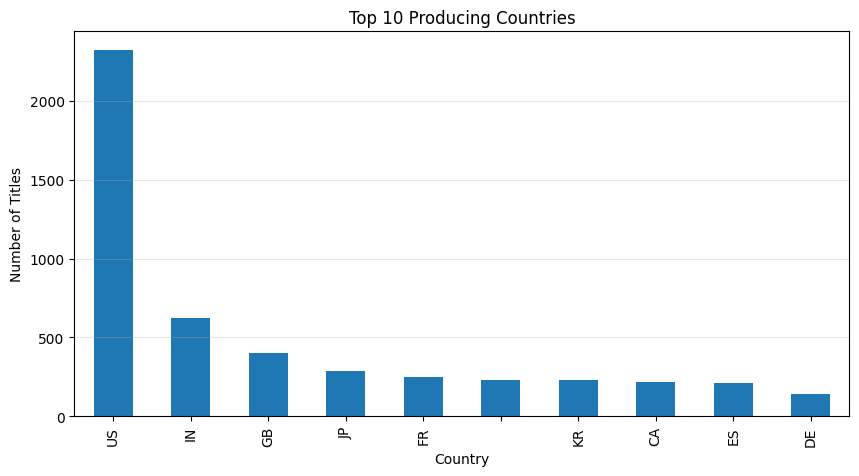

In [8]:
countries = (
    df["production_countries"]
    .dropna()
    .str.strip("[]")
    .str.replace("'", "", regex=False)
    .str.split(", ")
    .explode()
)

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")

plt.title("Top 10 Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Key Insight:**  
A small number of countries dominate content production.

**Interpretation:**  
Netflix relies heavily on major production hubs despite being a global platform.

## 7. Genre Distribution

**Goal:** Identify the most common genres on Netflix.

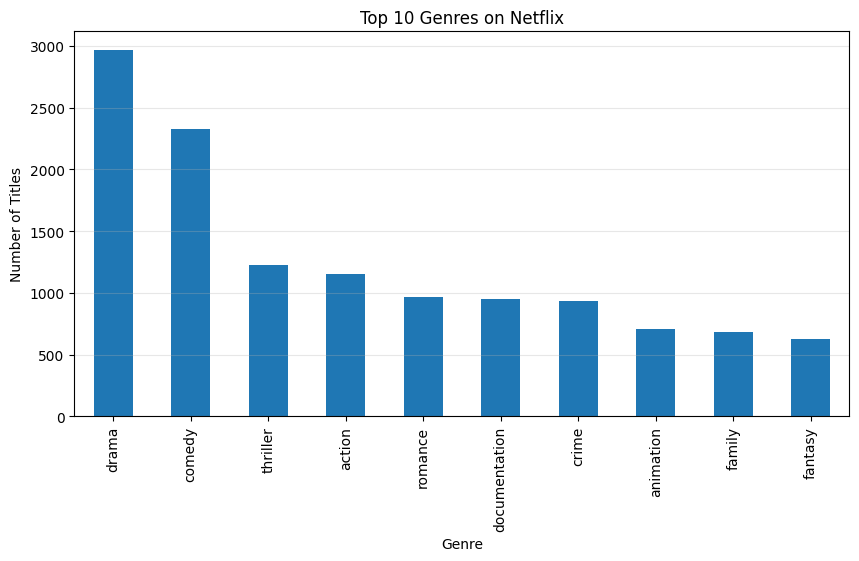

In [9]:
genres = (
    df["genres"]
    .dropna()
    .str.strip("[]")
    .str.replace("'", "", regex=False)
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind="bar")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Key Insight:**  
A limited number of genres dominate the platform.

**Interpretation:**  
Netflix prioritizes high-demand genres to maximize audience reach.

## Final Takeaways

- Netflix experienced rapid growth after 2010, peaking around 2019  
- Movies drove early expansion, while TV shows became more dominant later  
- TV shows generally receive higher IMDb ratings  
- Movie runtimes are decreasing, while TV show length remains stable  
- Content production is concentrated in a few key countries  
- A small number of genres dominate the catalog  

**Overall:**  
Netflix’s strategy reflects a shift toward scalable, globally produced, and engagement-driven content.